<a href="https://colab.research.google.com/github/ekaterinam164-arch/HW_3-Data-Analysis/blob/main/HW3.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Анализ данных и проверка статистических гипотез на материале датасета «Художественная проза о крестьянах в Российской империи 1772‒1861»

Изучим датасет по произведениям русской литературы (учитывая автопереводы с украинского) с крестянами в роли главных героев.

# Разведочный анализ данных, их очистка
Загрузим датасет и посмотрим на то, какими типами данных мы располагаем, и с какими из них мы будем работать в дальнейшем.

In [ ]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import scipy.stats

In [ ]:
df = pd.read_csv('https://raw.githubusercontent.com/ekaterinam164-arch/HW_3-Data-Analysis/refs/heads/main/index.tsv', sep='\t')
df

,no,author,pseudonym,title,subtitle,source,city,year,number_of_periodical_pagination,editions,narration,setting,region,location,protagonist_gender,protagonist_name_male,protagonist_name_female
0,1,автор не установлен,NaN,Колин и Лиза,сказка,Вечера,NaN,1772,Ч. 1. С. 193-200,NaN,3л,деревня,Великороссия,NaN,муж и жен,Колин,Лиза
1,2,"Чулков, Михаил Дмитриевич",NaN,Горькая участь,NaN,"Чулков М. Пересмешник, сказки славенские.",Москва,1789,Ч.5. С. 188-201,NaN,3л,деревня,Великороссия,NaN,муж,Сысой,нет
2,3,"Львов, Павел Юрьевич",NaN,Роза и Любим,сельская повесть,отд. изд.,Санкт-Петербург,1790,NaN,NaN,3л,деревня,Великороссия,NaN,муж и жен,Любим,Розы
3,4,"Карамзин, Николай Михайлович",NaN,"Фрол Силин, благодетельный человек",NaN,Московский журнал,NaN,1791,Ч. 3. Кн. 1. С. 31-47,NaN,3л,деревня,Великороссия,NaN,муж,Фрол,нет
4,5,"Карамзин, Николай Михайлович",NaN,Бедная Лиза,NaN,Московский журнал,NaN,1792,Ч. 6. Кн. 3. С. 238-277,NaN,3л (суб-авт),город,Великороссия,Москва,жен,Эраст,Лиза
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
230,231,"Славутинский, Степан Тимофеевич",NaN,Беглянка,роман,Русское слово,NaN,1861,No 8. Отд. I. С. 1–112; No 9. Отд. I. С. 1–134,"СПб., 1865",3л,деревня,Великороссия,NaN,жен,Кузька,Марья
231,232,"Петров, Михаил Александрович",NaN,Изуроченная,NaN,Библиотека для чтения,NaN,1861,Т. 168. No 12. Отд. I. С. 1–34,NaN,3л,имение,Великороссия,NaN,жен,Павел,Стеша
232,233,"Селиванов, Илья Васильевич",NaN,Два убийства,NaN,Современник,NaN,1861,No 5. Отд. I. С. 5–42,NaN,3л,деревня,Великороссия,NaN,жен,Емельян,Марья
233,234,"Успенский, Николай Васильевич",NaN,Зимний вечер,очерки народного быта,Современник,NaN,1861,No 1. Отд. I. С. 245–248,NaN,3л,деревня,Великороссия,NaN,муж и жен,без имени,без имени


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 235 entries, 0 to 234
Data columns (total 17 columns):
 #   Column                           Non-Null Count  Dtype 
---  ------                           --------------  ----- 
 0   no                               235 non-null    int64 
 1   author                           235 non-null    object
 2   pseudonym                        55 non-null     object
 3   title                            235 non-null    object
 4   subtitle                         127 non-null    object
 5   source                           235 non-null    object
 6   city                             48 non-null     object
 7   year                             235 non-null    int64 
 8   number_of_periodical_pagination  221 non-null    object
 9   editions                         43 non-null     object
 10  narration                        235 non-null    object
 11  setting                          235 non-null    object
 12  region                           235

In [ ]:
df.shape[0]

235

Это очень маленький датасет (что, впрочем, неудивительно). Проводить очистку значений в нем нужно очень осторожно и постараться свести ее к минимуму.

Наибольший интерес у меня вызвали следующие столбцы: год, тип повествования (narration), сеттинг, регион и пол главного героя/героини. В дальнейшем будем работать именно с ними.

## Год публикации
В датасете всего один столбец содержит в себе количественные данные — это год издания. Взглянем, в первую очередь, на него. Судя по тому, что в нем хранятся только целые числа, NaN там все-таки нет, но на всякий случай посмотрим, нет ли там его или его замены.

In [ ]:
df['year'].unique() # повезло

array([1772, 1789, 1790, 1791, 1792, 1795, 1796, 1798, 1803, 1804, 1807,
       1809, 1810, 1814, 1818, 1820, 1823, 1826, 1828, 1829, 1830, 1831,
       1832, 1834, 1837, 1838, 1839, 1840, 1841, 1842, 1843, 1844, 1845,
       1846, 1847, 1848, 1849, 1850, 1851, 1852, 1853, 1854, 1855, 1856,
       1857, 1858, 1859, 1860, 1861])

Посчитаем меры центральной тенденции: среднее значение, медиану и моду.

In [ ]:
print(f'Среднее: {df['year'].mean()}')
print(f'Медиана: {df['year'].median()}')
print(f'Мода: {df['year'].mode()}')

Среднее: 1847.2851063829787
Медиана: 1851.0
Мода: 0    1859
Name: year, dtype: int64


Все получившиеся значения получились довольно похожими и лежат в разбросе примерно в 10 лет. Уже глядя на них, можно сказать, что в данных точно существует перекос влево, и произведений, написанных после 1840-х годов в этом датасете гораздо больше, чем до.



Визуализируем распределение по годам. Для визуализации воспользуемся не только гистограммой, но и методом KDE, чтобы посмотреть на тренд.

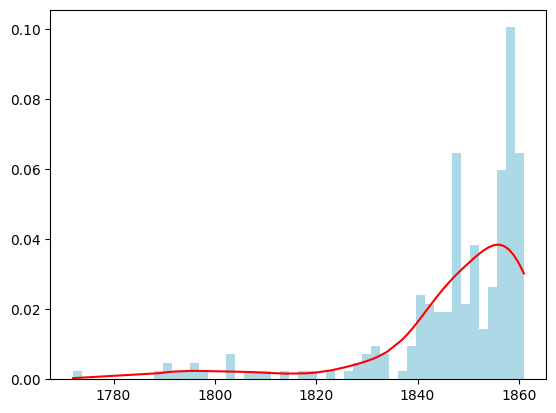

In [ ]:
from scipy.stats import gaussian_kde

data = df['year']
kde = gaussian_kde(data)
x = data.value_counts().sort_index().index

plt.hist(data, color='lightblue', density=True, bins=50)
plt.plot(x, kde(x), color='red')
plt.show()

Исходя из визуализации можно сделать подтвердить выводы, сделанные после расчета меры центральной тенденции. Мы действительно видим сильное смещение данных вправо и огромный всплеск публикаций произведений после 1840-х. Большая часть произведений написана именно в эти два десятилетия.

Проводить очистку по методу 1,5*IQR, как мне кажется не имеет особого смысла. Произведений до 1840-х действительно очень мало, но выкидывать их все бессмысленно для дальнейшего анализа. Вместо этого посмотрим, для каких лет у нас наименьшее количество произведений, и избавимся только от них.

## Декады

Вместо того, чтобы смотреть на отдельные годы публикации, гораздо эффективнее будет посмотреть распределение по десятилетиям. Создадим для него отдельный столбец.

In [ ]:
df['decade'] = df['year'].apply(lambda x: (x // 10) * 10)

Сделаем график, подобный тому, что мы делали для года публикации. Ничего нового он не скажет, но пусть побудет для красоты.

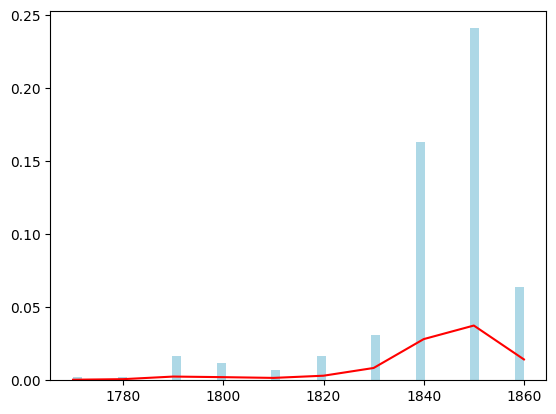

In [ ]:
data1 = df['decade']
kde1 = gaussian_kde(data1)
x1 = data1.value_counts().sort_index().index

plt.hist(data1, color='lightblue', density=True, bins=50)
plt.plot(x1, kde1(x1), color='red')
plt.show()

In [ ]:
df['decade'].value_counts()

,count
decade,
1850,102
1840,69
1860,27
1830,13
1820,7
1790,7
1800,5
1810,3
1780,1


До 1790-х мы видим всего 2 публикации в 1770-х и 1780-х соответственно. Посмотрим, что это за тексты, а после избавимся от них.

In [ ]:
df[(df['decade'] == 1770) | (df['decade'] == 1780)]

,no,author,pseudonym,title,subtitle,source,city,year,number_of_periodical_pagination,editions,narration,setting,region,location,protagonist_gender,protagonist_name_male,protagonist_name_female,decade
0,1,автор не установлен,NaN,Колин и Лиза,сказка,Вечера,NaN,1772,Ч. 1. С. 193-200,NaN,3л,деревня,Великороссия,NaN,муж и жен,Колин,Лиза,1770
1,2,"Чулков, Михаил Дмитриевич",NaN,Горькая участь,NaN,"Чулков М. Пересмешник, сказки славенские.",Москва,1789,Ч.5. С. 188-201,NaN,3л,деревня,Великороссия,NaN,муж,Сысой,нет,1780


In [ ]:
df = df[df['decade'] > 1780]

In [ ]:
df['decade'].value_counts()

,count
decade,
1850,102
1840,69
1860,27
1830,13
1820,7
1790,7
1800,5
1810,3


## Промежуточные выводы

Посмотреть на тенденцию публикацю произведений про крестьян по декадам уже само по себе интересно. В 1770-х и 80-х, в годы правления Екатерины II, их практически нет: на такой результат влияют и положение крестьян в обществе в целом — с 60-х по 80-х происходит окончательное закрепощение крестьян — цензура (в том числе, и самоцензура), а также память о крестьянских восстаниях.



Уже с 1790-х количество произведений про крестьян выросло с 1 в предыдущем десятилетии до 7. Возможно, увеличение интереса связано не только с окончанием правления Екатерины II, но даже в большей степени с «Бедной Лизой» Карамзина, которая вышла как раз с 1792 г. и с которой фактически началось становление сентиментализма в русской литературе, учитывая ее бешеную популярность в те времена.

В период с 1800-х по 1820-е количество произведений примерно такое же низкое, хоть оно и чуть выросло. В 30-е количество текстов снова незначительно увеличилось, но зато в 40-е, во времена николаевской цензуры, произошел бум: опубликованы почти 70 текстов про крестьян. Тут, возможно, глобально повлияли декабристы и распространение всяческих политических кружков в кулуарах. В общественной мысли все больше внимания интеллектуалы уделяют крестьянам и их положению, и эти идеи так или иначе влияют и на развитие художественной литературы. Интерес к теме однозначно вырос.

Я бы связала этот интерес не только с политическими факторами, но и с национальной риторикой. В Европе и Российской империи в том числе начинается наациональное строительство: формируется образ европейских наций. Процесс идет не только сверху (как Николай и его приближенные формировали национальную русскую идею, можно говорить долго), но и снизу. Естественно, самой большой и, по идее, самой заметной группой внутри одной большой нации должно стать крестьянство как воплощение идеи глубинного народа.

С 1848 г. начинается «мрачное семилетие» правления Николая I, продлившееся до самой его смерти, и окончательное ужесточение цензуры, но количество текстов о крестьянах только растет. После прихода к власти Александра II тенденция продолжается, а к ней добавляются и повсеместные обсуждения необходимости отмены крепостного права. Крестьяне в это время действительно находятся в центре внимания. Стоит также отметить, что фактически 1860-е представлены только двумя годами, но в преддверии отмены крепостного права о крестьянах было написано целых 27 текстов.

## Повествование

Посмотрим, от чьего лица чащего всего ведется повествование, взглянув на моду.

In [ ]:
print(f'Мода: {df['narration'].mode()}')

Мода: 0    3л
Name: narration, dtype: object


Для визуализации распределения построим столбчатую диаграмму.

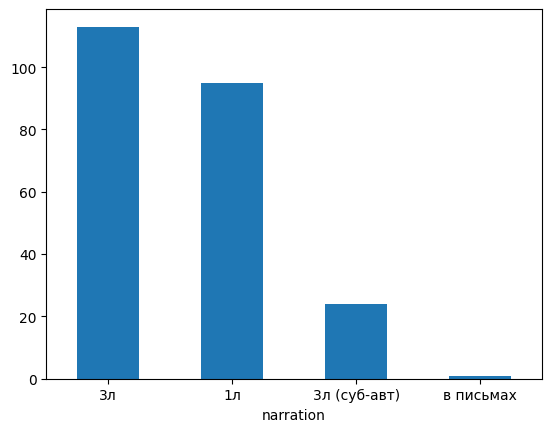

In [ ]:
plt.figure()
df['narration'].value_counts().plot(kind='bar')
plt.xticks(rotation=0)
plt.show()

Неожиданно для себя обнаружила, что количество произведений с наррацией от 3-го лица, хотя и несколько больше произведений с нарацций от 1-го лица, но  разрыв между ними совершенно не критический. Тип повествования «в письмах» содержит, в свою очередь, самое маленькое количество произведений. На этом этапе мы пока не будем избавляться от категориальных данных — количество произведений и так невелико, так что пока что не будем делать датасет еще меньше.

Интересная категория, которая здесь встречается — 3л (суб-авт). В README-файле к датасету указано, что за ним скрывается субъективно-авторский тип наррации. Он подразумевает, что произведение, формально начинаясь как текст, написанный от 1-го лица, но плавно перетекающее в повествование от 3-го. Такой тип, например, встречается у Карамзина в «Бедной Лизе».

Хотя таких произведений относительно немного, мы все же оставим эту категорию в датасете, не соединяя ее с обычным повествованием от 3-го лица.

## Сеттинг

Под сеттингом в датасете подразумевается место действия в самом общем смысле. Снова визуализируем, чтобы сравнить распределение.

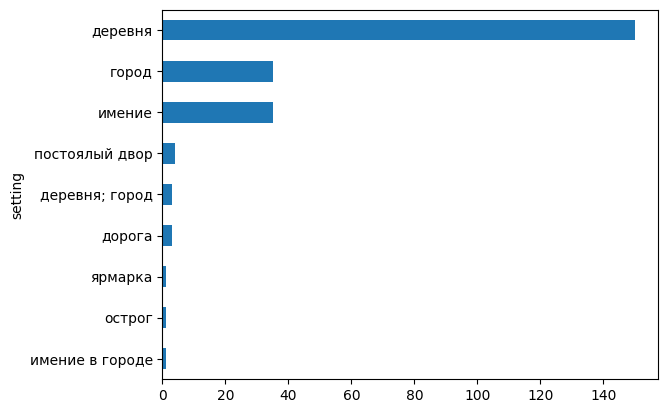

In [ ]:
plt.figure()
df['setting'].value_counts().sort_values(ascending=True).plot(kind='barh')
plt.show()

Отчетливо видим по графику, что в топ-3 сеттинга входят деревня, город и имение с огромным отрывом от всех остальных, причем, деревня в разы более часто встречающийся сеттинг, чем город и имение вместе взятые.

## Регион

Тут мы посмотрим на конкретный регион, в котором происходят события в произведениях. Визуализируем так же, как остальные столбцы.

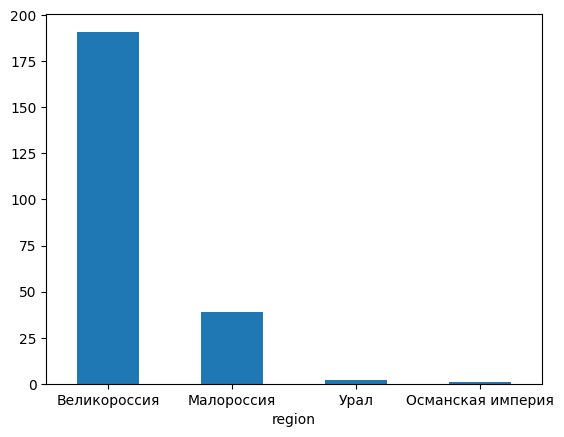

In [ ]:
plt.figure()
df['region'].value_counts().plot(kind='bar')
plt.xticks(rotation=0)
plt.show()

Большая часть произведений происходит в Великороссии (территория современной России). Гораздо меньше — в Малороссии (преимущественно современная Украина). И только в единичных текстах действие происходит на Урале и, как ни странно, в Османской империи. Посмотрим, что это за произведение.

In [ ]:
df[df['region'] == 'Османская империя']

,no,author,pseudonym,title,subtitle,source,city,year,number_of_periodical_pagination,editions,narration,setting,region,location,protagonist_gender,protagonist_name_male,protagonist_name_female,decade
87,88,"Даль, Владимир Иванович",NaN,Беглянка,картины из русского быта,Отечественные записки,NaN,1848,No 2. Отд. 1. С. 234–243.,NaN,1л,деревня,Османская империя,Турция,жен,Степан,Улита,1840


## Пол главного героя/героини

И, наконец, взглянем на распределения пола.

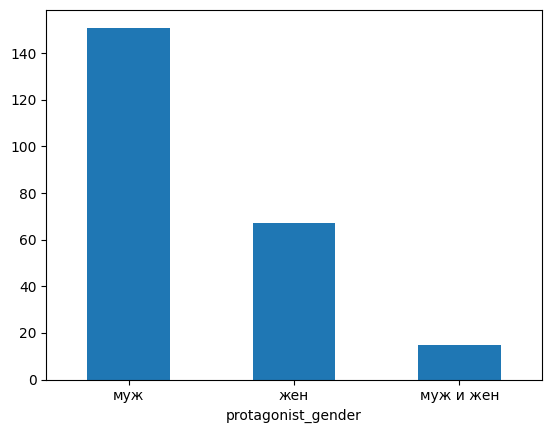

In [ ]:
plt.figure()
df['protagonist_gender'].value_counts().plot(kind='bar')
plt.xticks(rotation=0)
plt.show()

Здесь мы видим сразу 3 категории: мужской, женский и мужской вместе с женским, если есть сразу 2 главных героя.

# Корреляционный анализ


## Связь десятилетия издания и пола главного героя/героини

В этом датасете всего один столбец содержит количественные значения. Однако, чтобы провести корреляционный анализ, пол можно представить в виде бинарных данных.

Я хочу узнать, существует ли какая-либо корреляция между десятилетием издания произведения и полом главного героя: возможно, в течении 70 лет предпочтения авторов в этом вопросе менялись. Чтобы узнать это я буду использовать **точечно-бисериальный коэффициент корреляции** — частный случай коэффициента Пирсона, который позволяет оценить связь между бинарной и количественной переменными.

Для начала создадим новый датафрейм, где избавимся от произведений с двумя главными героями.

In [ ]:
df_genders = df[df['protagonist_gender'] != 'муж и жен'].copy()
df_genders['protagonist_gender']

,protagonist_gender
3,муж
4,жен
5,муж
7,жен
8,муж
...,...
229,муж
230,жен
231,жен
232,жен


Заменим пол на бинарные значения.

In [ ]:
df_genders['gender_coded'] = df_genders['protagonist_gender'].map({'муж': 0, 'жен': 1})
df_genders['gender_coded']

,gender_coded
3,0
4,1
5,0
7,1
8,0
...,...
229,0
230,1
231,1
232,1


In [ ]:
df_genders_corr = scipy.stats.pointbiserialr(df_genders['decade'], df_genders['gender_coded'])
df_genders_corr

SignificanceResult(statistic=np.float64(-0.10837842791856542), pvalue=np.float64(0.11055751321430055))

При подсчете коэффициента мы получили отрицательное число, которая, по идее, обозначает обратную связь между признаками: с течением времени стали авторы якобы стали больше писать про мужчин. Однако стоит учесть, во-первых, очень низкое абсолютное значение корреляции - всего 0,1 - и крайне низкое значение p-value — тоже примерно 0,1.

Это означает, что связи между полом героя/героини и десятилетием не наблюдается, а обратная связь корреляции носит случайный характер.

## Визуализация

Посмотрим наглядно, как распределяется категория **protaginist_gender** по десятилетиям.

In [ ]:
import plotly.express as px

In [ ]:
color_map = {
    'муж': 'blue',
    'жен': 'pink',
    }

fig_plotly = px.histogram(
    df_genders,
    x='decade',
    color='protagonist_gender',
    category_orders={'protagonist_gender': ['жен', 'муж']},
    color_discrete_map=color_map,
    barmode='stack',
    range_x=[1790, 1861]
)

fig_plotly.update_layout(
    yaxis_title="число",
    xaxis_title="десятилетие",
    legend_title="пол"
)

fig_plotly.show()

Как и ожидалось, мужчин в роли главных героев гораздо больше. Но Вв1800-х можно заметить какую-то удивительную картину, когда число мужских персонажей в первый (и последний) раз не превалирует. Про мужчин-крестьян в эти 10 лет не писали в принципе, даже в качестве второго главного героя, как это можно увидеть по нашему изначальному датасету.

Невероятная щедрость от авторов этого периода — видимо, благодарить мы за это должны волну сентиментализма и моду на сентиментальных героинь, установленную Карамзиным.

In [ ]:
df[(df_genders['decade'] == 1800) & (df['protagonist_gender'] == 'муж и жен')].shape[0]

0

In [ ]:
df_genders[(df_genders['decade'] == 1800) & (df_genders['protagonist_gender'] == 'жен')].shape[0] # именно столько суммарно было произведеный было за эти годы, так что ни один текст даже не отсеялся при очистке

5

# Проверка статистических гипотез

## Потенциальная зависимость сеттинга от региона

Я хочу проверить, существует ли какая-либо статистически значимая связь между выбором региона в повествовании и сеттингом. Выдвину гипотезы, а для их проверки я буду использовать 𝜒2-критерий Пирсона.

Нулевая гипотеза (H₀): регион и сеттинг независимы.

Альтернативная гипотеза (H₁): между регионом и сеттингом существует связь.

α = 0.05

Для начала избавимся от нерелевантных данных. Как мы увидели при разведочном анализе данных, основную массу сеттингов составляют деревня, город и имении. Оставим в датасете только их.

In [ ]:
df_filtered = df[(df['setting'] == 'деревня') | (df['setting'] == 'город') | (df['setting'] == 'имение')].copy()
df_filtered.shape[0]

220

Проделаем то же самое со столбцом с регионами и оставим только Великороссию и Малороссию.

In [ ]:
df_filtered = df_filtered[(df_filtered['region'] == 'Великороссия') | (df_filtered['region'] == 'Малороссия')]
df_filtered.shape[0]

217

После очистки датасета построим таблицу сопряженности.

In [ ]:
crosstable = pd.crosstab(df_filtered['region'], df_filtered['setting'])
crosstable # где-то значений маловато, но рискнем

setting,город,деревня,имение
region,,,
Великороссия,28,118,32
Малороссия,6,30,3


In [ ]:
scipy.stats.chi2_contingency(crosstable)

Chi2ContingencyResult(statistic=np.float64(2.6307358403194487), pvalue=np.float64(0.2683755642921663), dof=2, expected_freq=array([[ 27.88940092, 121.40092166,  28.70967742],
       [  6.11059908,  26.59907834,   6.29032258]]))

По крошечному значению p-value видно, что никакой связи нет, но, на самом деле,примерно то же самое можно сказать и просто глядя на таблицу сопряженности. Оснований отвергнуть нулевую гипотезу у нас нет, а потому мы можем утверждать, что сеттинг скорее не зависим от региона.

Отсутствие связи легко объясняется тем, в каких местах проживали крестьяне. Совершенно логично, что в большинстве произведений, вне зависимости от региона действия, сеттинг точно так же будет деревенским.

## Визуализация

Проиллюстрируем также эти данные в виде тепловой карты.

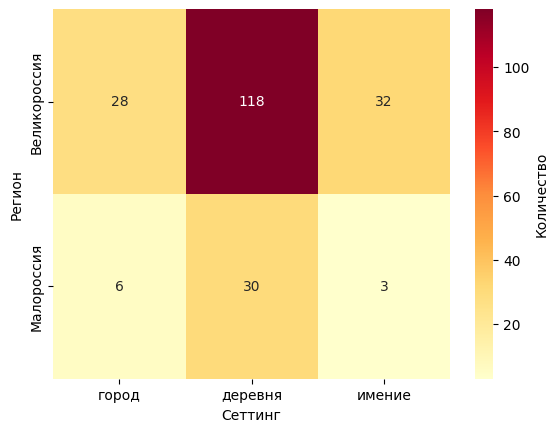

In [ ]:
plt.figure()
sns.heatmap(crosstable, annot=True, fmt='d', cmap='YlOrRd', cbar_kws={'label': 'Количество'})
plt.xlabel('Сеттинг')
plt.ylabel('Регион')
plt.show()

# Потенциальная зависимость выбора типа повествования от десятилетия издания

Здесь мы проверим, менялась ли литературная мода с выбором типа повествования в течении времени или же нет. Все также будем проверять гипотезы при помощи 𝜒2-критерия Пирсона.

Нулевая гипотеза (H₀): выбор типа наррации не зависит от десятилетия.

Альтернативная гипотеза (H₁): выбор типа наррации зависит от десятилетия.

α = 0.05

Избавимся от ненужных данных и выбросим тот единственный случай употребления типа наррации «в письмах».

In [ ]:
df_filtered2 = df[df['narration'] != 'в письмах']

Снова строим таблицу сопряженности.

In [ ]:
crosstable2 = pd.crosstab(df_filtered2['decade'], df_filtered['narration'])
crosstable2

narration,1л,3л,3л (суб-авт)
decade,,,
1790,4,2,1
1800,2,1,2
1810,1,1,1
1820,2,3,1
1830,4,7,1
1840,23,31,11
1850,43,48,4
1860,9,14,0


Таблица мне не очень нравится, но сначала по пробуем на ней, а потом при надобности почистим.

In [ ]:
scipy.stats.chi2_contingency(crosstable2)

Chi2ContingencyResult(statistic=np.float64(19.780666553080724), pvalue=np.float64(0.13720955544460794), dof=14, expected_freq=array([[ 2.85185185,  3.46759259,  0.68055556],
       [ 2.03703704,  2.47685185,  0.48611111],
       [ 1.22222222,  1.48611111,  0.29166667],
       [ 2.44444444,  2.97222222,  0.58333333],
       [ 4.88888889,  5.94444444,  1.16666667],
       [26.48148148, 32.19907407,  6.31944444],
       [38.7037037 , 47.06018519,  9.23611111],
       [ 9.37037037, 11.39351852,  2.23611111]]))

Снова низкий p-value (всего 0.14). Попробуем убрать столбцы, где значения совсем уж низкие.

In [ ]:
crosstable2 = crosstable2[3:7]
crosstable2

narration,1л,3л,3л (суб-авт)
decade,,,
1820,2,3,1
1830,4,7,1
1840,23,31,11
1850,43,48,4


In [ ]:
scipy.stats.chi2_contingency(crosstable2)

Chi2ContingencyResult(statistic=np.float64(8.29545923632611), pvalue=np.float64(0.21724646500990927), dof=6, expected_freq=array([[ 2.42696629,  3.        ,  0.57303371],
       [ 4.85393258,  6.        ,  1.14606742],
       [26.29213483, 32.5       ,  6.20786517],
       [38.42696629, 47.5       ,  9.07303371]]))

Уже лучше, но p-value все равно низкий (0.22), а это значит, что оснований отвергнуть нулевую гипотезу у нас нет. Ни одна гипотеза или предположение о возможной корреляции на этом датасете не подтвердились. Очень жаль :(

## Визуализация

Напоследок проиллюстрируем тенденции (точнее, их отсутствие) при помощи лайнплота.

In [ ]:
crosstable2 = pd.crosstab(df_filtered2['decade'], df_filtered['narration']) # вернем изначальные данные

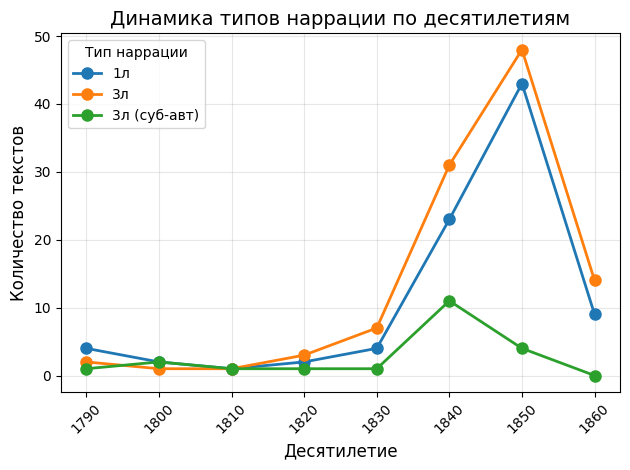

In [ ]:
plt.figure()

for col in crosstable2.columns:
    plt.plot(crosstable2.index, crosstable2[col], marker='o', linewidth=2,
             markersize=8, label=col)

plt.title('Типы наррации по десятилетиям', fontsize=14)
plt.xlabel('Десятилетие', fontsize=12)
plt.ylabel('Количество текстов', fontsize=12)
plt.legend(title='Тип наррации')
plt.grid(True, alpha=0.3)
plt.xticks(crosstable2.index, rotation=45)
plt.tight_layout()
plt.show()

# Декларация об использовании ИИ

В этой работе использовался ИИ:

1. В пункте с корреляционным анализом — ИИ я использовала, чтобы узнать, при помощи каких методов можно определять корреляции с бинарными данными.

2. В визуализациях — ИИ исправил некоторые ошибки в визуализации в пункте с корреляционным анализом. Последний график я с некоторыми собственными исправлениями навайбкодила.